In [4]:
from pathlib import Path

REPO_ROOT = Path(r"C:\Users\Jacob\AI4Mars")
DATASET_ROOT = REPO_ROOT / "data" / "raw" / "ai4mars" / "ai4mars-dataset-merged-0.6"
MANIFEST_ROOT = REPO_ROOT / "artifacts" / "manifests"
CONFIG_PATH = REPO_ROOT / "configs" / "reproduction" / "paper_deeplabv3plus_kaggle_p100.yaml"
CHECKPOINT_PATH = REPO_ROOT / "artifacts" / "ai4mars-paper-reproduction" / "frozen" / "deeplabv3plus-tesla-p100-seed42-best-val-miou.pth"
OUTPUT_DIR = REPO_ROOT / "outputs" / "figures" / "correct_prediction_overlays"
SPLIT_NAME = "val"

In [5]:
import sys
sys.path.insert(0, str(REPO_ROOT))

import torch
from torch.utils.data import DataLoader

from src.dataset import AI4MarsDataset, load_pairs_from_manifest
from src.paper_model import build_deeplabv3plus, CLASS_MAPPING
from src.paper_train import load_and_validate_config

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = load_and_validate_config(CONFIG_PATH, enforce_training_batch_size=False)
spec = config["paper_model_spec"]

pairs = load_pairs_from_manifest(
    MANIFEST_ROOT / config["data"][f"{SPLIT_NAME}_manifest"],
    dataset_root=DATASET_ROOT,
    required_label_scheme="NAV",
    require_shape_match=True,
)
dataset = AI4MarsDataset(
    pairs,
    image_size=spec.input_size,
    require_original_shape_match=True,
    normalization_mean=spec.normalization_mean,
    normalization_std=spec.normalization_std,
)
loader = DataLoader(dataset, batch_size=int(config["training"]["batch_size"]), shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_deeplabv3plus(spec).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded checkpoint epoch {checkpoint.get('epoch')} on {device}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

c:\Users\Jacob\AI4Mars\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Jacob\.cache\huggingface\hub\models--smp-hub--resnet101.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

Loaded checkpoint epoch 25 on cuda


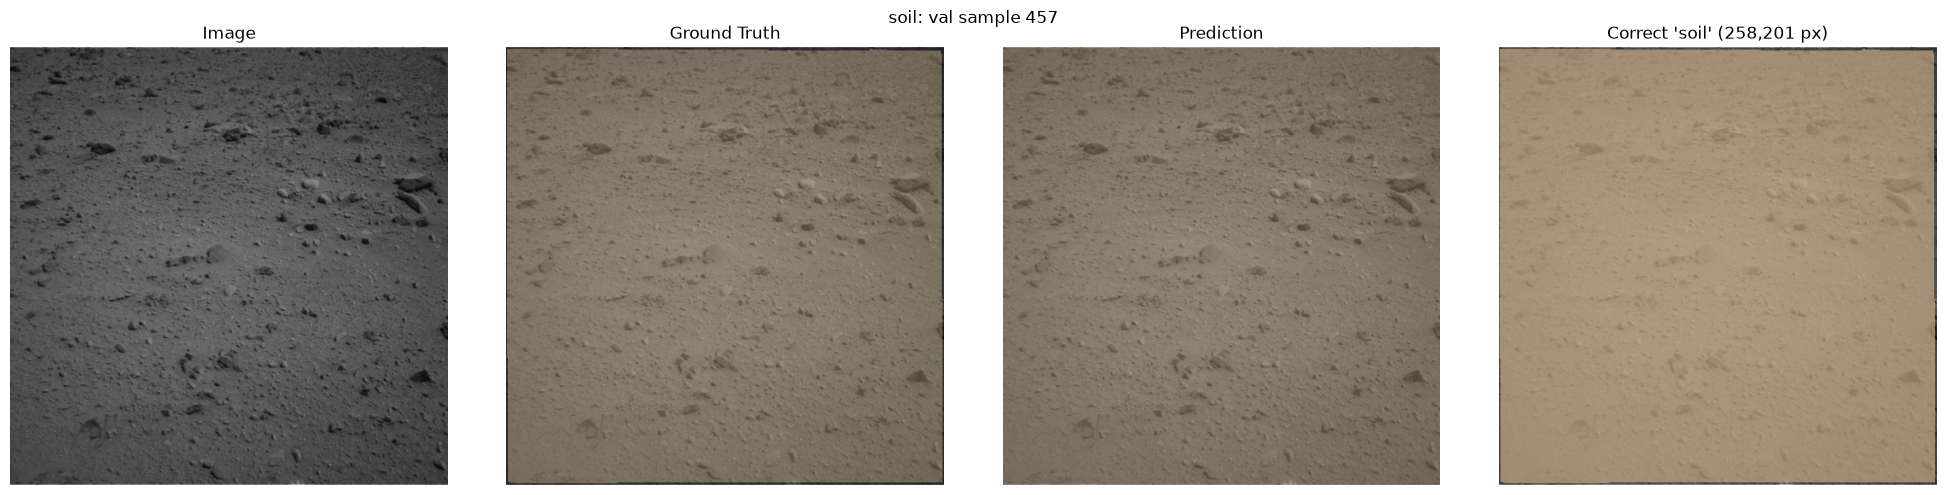

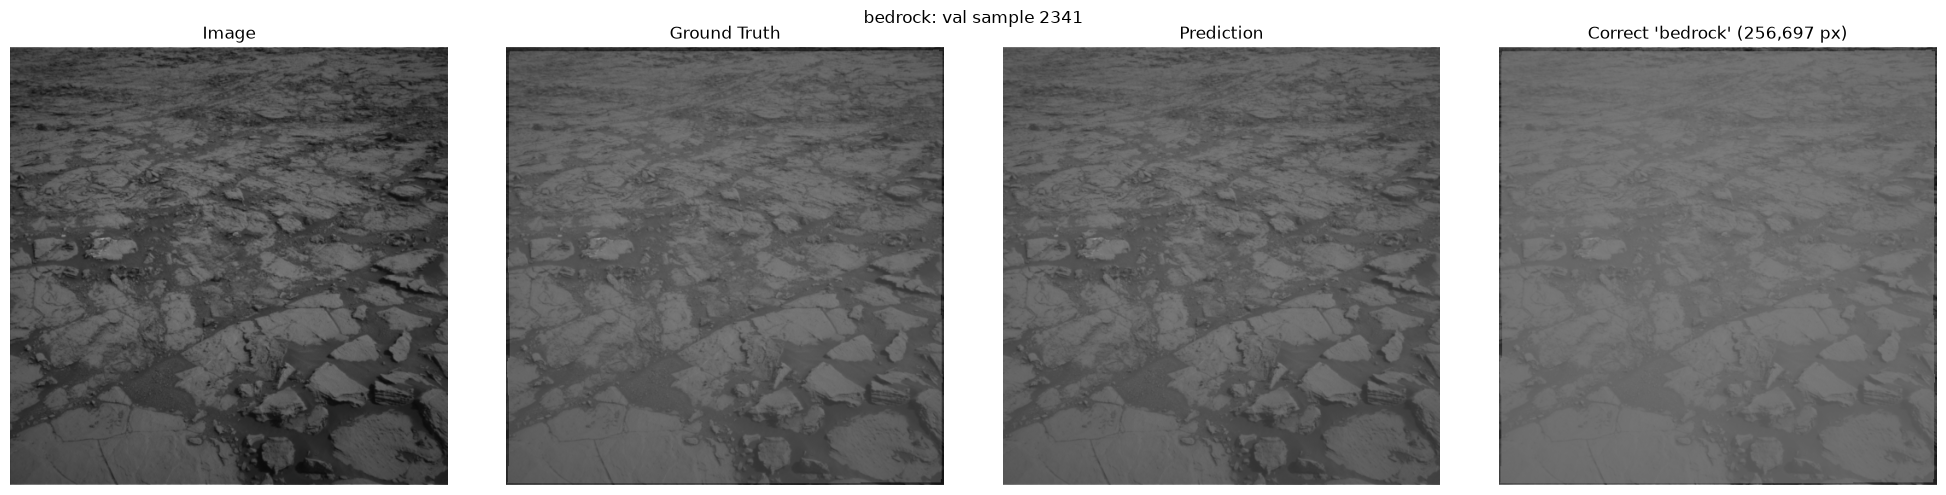

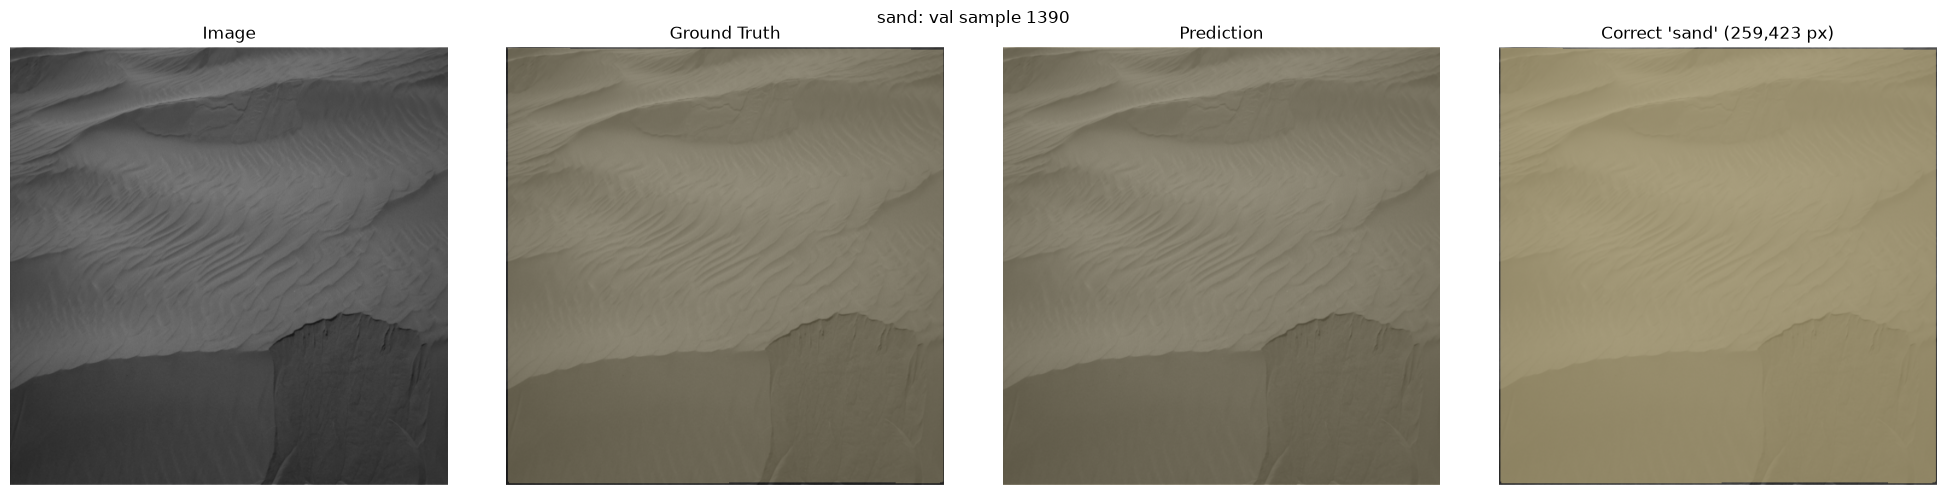

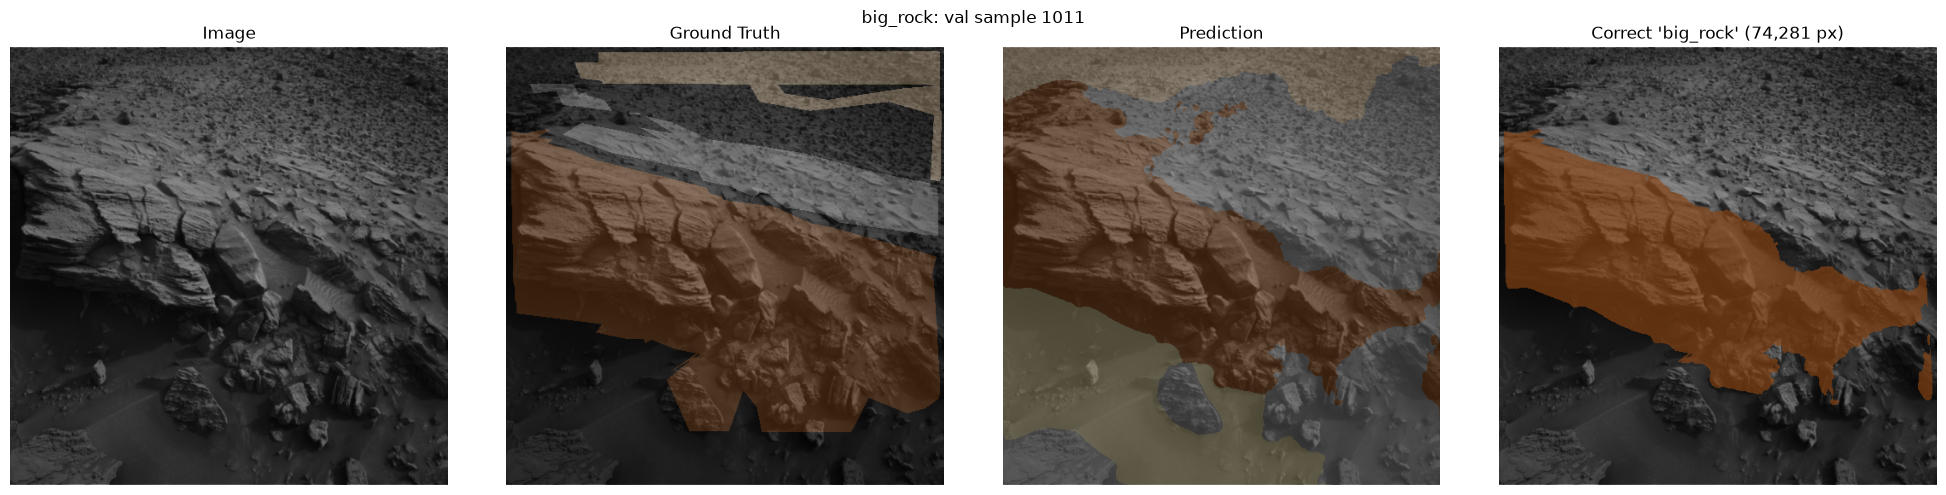

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from src.visualize import show_image, show_image_mask_overlay, CLASS_COLORS

mean = torch.tensor(spec.normalization_mean).view(3, 1, 1)
std = torch.tensor(spec.normalization_std).view(3, 1, 1)

# Per class: (correct_pixel_count, sample_index, prediction, target)
best = {class_id: (-1, None, None, None) for class_id in CLASS_MAPPING}

offset = 0
with torch.no_grad():
    for images, targets in loader:
        preds = model(images.to(device)).argmax(dim=1).cpu()
        for i in range(images.shape[0]):
            for class_id in CLASS_MAPPING:
                count = int(((preds[i] == class_id) & (targets[i] == class_id)).sum())
                if count > best[class_id][0]:
                    best[class_id] = (count, offset + i, preds[i], targets[i])
        offset += images.shape[0]

for class_id, class_name in CLASS_MAPPING.items():
    count, index, pred, target = best[class_id]
    if index is None:
        print(f"No correctly-predicted pixels found for '{class_name}'.")
        continue

    image = (dataset[index][0] * std + mean).clamp(0.0, 1.0).permute(1, 2, 0).numpy()
    pred_np, target_np = pred.numpy(), target.numpy()

    # Tint only the pixels where prediction and ground truth agree on this class.
    correct = (pred_np == class_id) & (target_np == class_id)
    color = np.array(CLASS_COLORS[class_id]) / 255.0
    tinted = image.copy()
    tinted[correct] = 0.35 * image[correct] + 0.65 * color

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    show_image(image, title="Image", ax=axes[0])
    show_image_mask_overlay(image, target_np, title="Ground Truth", ax=axes[1])
    show_image_mask_overlay(image, pred_np, title="Prediction", ax=axes[2])
    axes[3].imshow(tinted)
    axes[3].set_title(f"Correct '{class_name}' ({count:,} px)")
    axes[3].axis("off")
    fig.suptitle(f"{class_name}: {SPLIT_NAME} sample {index}")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"correct_{class_name}.png", dpi=150, bbox_inches="tight")
    plt.show()